In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [3]:
url = "https://raw.githubusercontent.com/mwaskom/seaborn-data/master/penguins.csv"

df = pd.read_csv(url)

df.head()

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,MALE
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,FEMALE
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,FEMALE
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,FEMALE


In [4]:
print("Shape:")
print(df.shape)

print("\nColumns:")
print(df.columns.tolist())

print("\nData types:")
print(df.dtypes)

print("\nNull counts:")
print(df.isnull().sum())

print("\nUnique values:")
print(df.nunique())

Shape:
(344, 7)

Columns:
['species', 'island', 'bill_length_mm', 'bill_depth_mm', 'flipper_length_mm', 'body_mass_g', 'sex']

Data types:
species                  str
island                   str
bill_length_mm       float64
bill_depth_mm        float64
flipper_length_mm    float64
body_mass_g          float64
sex                      str
dtype: object

Null counts:
species               0
island                0
bill_length_mm        2
bill_depth_mm         2
flipper_length_mm     2
body_mass_g           2
sex                  11
dtype: int64

Unique values:
species                3
island                 3
bill_length_mm       164
bill_depth_mm         80
flipper_length_mm     55
body_mass_g           94
sex                    2
dtype: int64


## Task 1: Dataset Selection and Schema Report

### Dataset
Palmer Penguins dataset.

### Source
Palmer Penguins dataset, publicly available through the seaborn sample dataset repository.

### Why I chose this dataset
I chose this dataset because it contains more than 200 rows and includes both numerical and categorical variables. It is suitable for practicing data cleaning, GroupBy aggregation, merging, NumPy computation, and exploratory visualization.

### License
The dataset is publicly available. The dataset's source and license information should be checked and documented before submission.

In [5]:
df.isnull().sum()

species               0
island                0
bill_length_mm        2
bill_depth_mm         2
flipper_length_mm     2
body_mass_g           2
sex                  11
dtype: int64

In [7]:
df_clean = df.copy()

# Remove rows with missing values because the missing rows are few
# and the remaining dataset is still large enough for analysis.
df_clean = df_clean.dropna()

In [8]:
print("Shape before cleaning:", df.shape)
print("Shape after cleaning:", df_clean.shape)

print("\nMissing values after cleaning:")
print(df_clean.isnull().sum())

Shape before cleaning: (344, 7)
Shape after cleaning: (333, 7)

Missing values after cleaning:
species              0
island               0
bill_length_mm       0
bill_depth_mm        0
flipper_length_mm    0
body_mass_g          0
sex                  0
dtype: int64


In [9]:
print("Number of duplicate rows:", df_clean.duplicated().sum())

Number of duplicate rows: 0


In [11]:
df_clean = df_clean.drop_duplicates()

In [10]:
print("Shape after removing duplicates:", df_clean.shape)

Shape after removing duplicates: (333, 7)


In [12]:
print(df_clean.dtypes)

species                  str
island                   str
bill_length_mm       float64
bill_depth_mm        float64
flipper_length_mm    float64
body_mass_g          float64
sex                      str
dtype: object


In [13]:
species_stats = (
    df_clean
    .groupby("species")
    .agg(
        average_body_mass=("body_mass_g", "mean"),
        average_flipper_length=("flipper_length_mm", "mean")
    )
    .reset_index()
)

species_stats

,species,average_body_mass,average_flipper_length
0,Adelie,3706.164384,190.102740
1,Chinstrap,3733.088235,195.823529
2,Gentoo,5092.436975,217.235294


In [15]:
print("Shape before merge:", df_clean.shape)

df_clean = df_clean.merge(
    species_stats,
    on="species",
    how="left"
)

print("Shape after merge:", df_clean.shape)

Shape before merge: (333, 9)
Shape after merge: (333, 11)


In [16]:
body_mass = df_clean["body_mass_g"].to_numpy()

In [17]:
body_mass_normalized = (
    (body_mass - np.mean(body_mass))
    / np.std(body_mass)
)

In [18]:
print("Mean:", np.mean(body_mass_normalized))
print("Standard deviation:", np.std(body_mass_normalized))
print("Minimum:", np.min(body_mass_normalized))
print("Maximum:", np.max(body_mass_normalized))

Mean: -1.70700957539964e-16
Standard deviation: 0.9999999999999999
Minimum: -1.874435413639854
Maximum: 2.603143890677087


In [19]:
df_clean["body_mass_standardized"] = body_mass_normalized

In [20]:
df_clean.head()

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex,average_body_mass_x,average_flipper_length_x,average_body_mass_y,average_flipper_length_y,body_mass_standardized
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,MALE,3706.164384,190.10274,3706.164384,190.10274,-0.568475
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,FEMALE,3706.164384,190.10274,3706.164384,190.10274,-0.506286
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,FEMALE,3706.164384,190.10274,3706.164384,190.10274,-1.190361
3,Adelie,Torgersen,36.7,19.3,193.0,3450.0,FEMALE,3706.164384,190.10274,3706.164384,190.10274,-0.941606
4,Adelie,Torgersen,39.3,20.6,190.0,3650.0,MALE,3706.164384,190.10274,3706.164384,190.10274,-0.692852


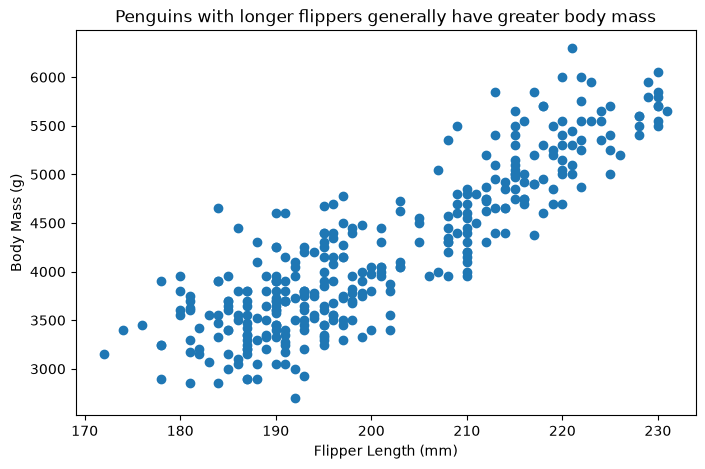

In [24]:
plt.figure(figsize=(8, 5))

plt.scatter(
    df_clean["flipper_length_mm"],
    df_clean["body_mass_g"]
)

plt.xlabel("Flipper Length (mm)")
plt.ylabel("Body Mass (g)")
plt.title("Penguins with longer flippers generally have greater body mass")

plt.savefig(
    "../reports/a2_chart1.png",
    dpi=150,
    bbox_inches="tight"
)

plt.show()

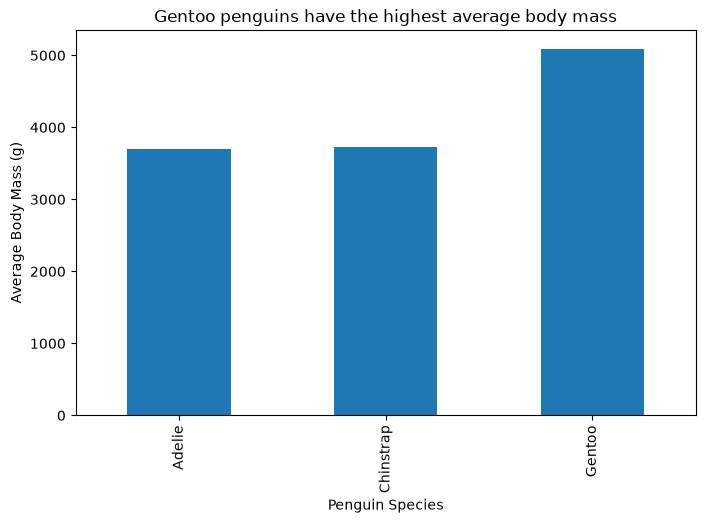

In [25]:
species_mass = df_clean.groupby("species")["body_mass_g"].mean()

plt.figure(figsize=(8, 5))

species_mass.plot(kind="bar")

plt.xlabel("Penguin Species")
plt.ylabel("Average Body Mass (g)")
plt.title("Gentoo penguins have the highest average body mass")

plt.savefig(
    "../reports/a2_chart2.png",
    dpi=150,
    bbox_inches="tight"
)
plt.show()

In [28]:
df_clean.to_csv(
    "../data/processed/penguins_cleaned.csv",
    index=False
)